In [13]:
from google.colab import files
files = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [14]:
import pandas as pd

df = pd.read_csv ('Telco-Customer-Churn.csv')

print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum())

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   ob

The dataset contains 7,043 customer records and 21 variables related to customer demographics, subscription services, billing information, and churn status. Data quality checks revealed no missing values across any columns. The dataset was therefore considered suitable for analysis without requiring data imputation.

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [16]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())

float64
11


During data preparation, the TotalCharges field was converted from text to numeric format. This process revealed 11 missing values (0.16% of the dataset). Given the very small proportion of affected records, the missing values were considered unlikely to materially impact the analysis.

In [17]:
df = df.dropna(subset=['TotalCharges'])

In [18]:
print(df.shape)
print(df['TotalCharges'].isnull().sum())

(7032, 21)
0


## Churn Rate


In [19]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Approximately 26.6% of customers have left the company, meaning that more than one in four customers churned. This represents a significant retention challenge and highlights the need for targeted customer retention strategies.

In [20]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


Analysis revealed that customers on month-to-month contracts have a churn rate almost four times higher than customers on one-year contracts and fifteen times higher than customers on two-year contracts. Increasing adoption of long-term contracts could significantly reduce customer attrition and improve recurring revenue.

In [21]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


The company should review pricing strategies for higher-cost plans and assess whether customers perceive sufficient value for the price they are paying. Introducing loyalty discounts, bundled services, or enhanced customer support may help improve retention among higher-paying customers.

## Customer Tenure

In [22]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


The company should focus on improving the customer experience during the first 18 months of the customer lifecycle. Enhanced onboarding, proactive customer support, and targeted engagement campaigns could significantly reduce churn among newer customers.

## Internet Service

In [23]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


The company should investigate customer satisfaction, pricing, service reliability, and support experiences among Fiber Optic customers. Reducing churn within this segment could have a significant positive impact on revenue and customer lifetime value.

## Tech Support VS Churn

In [24]:
pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [25]:
pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


## Churn Distribution

In [27]:
import os

os.makedirs('images', exist_ok=True)

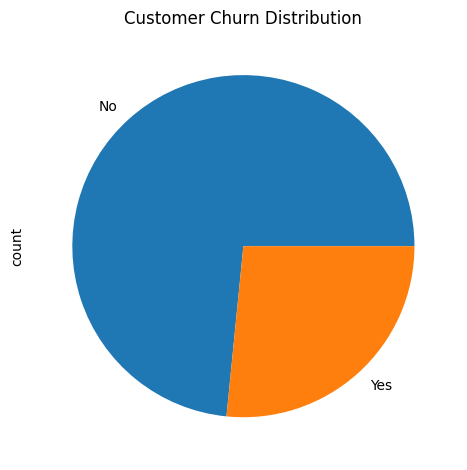

In [29]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='pie')
plt.title('Customer Churn Distribution')
plt.tight_layout()
plt.savefig('images/churn_distribution.png')
plt.show()

## Contract Type vs Chur

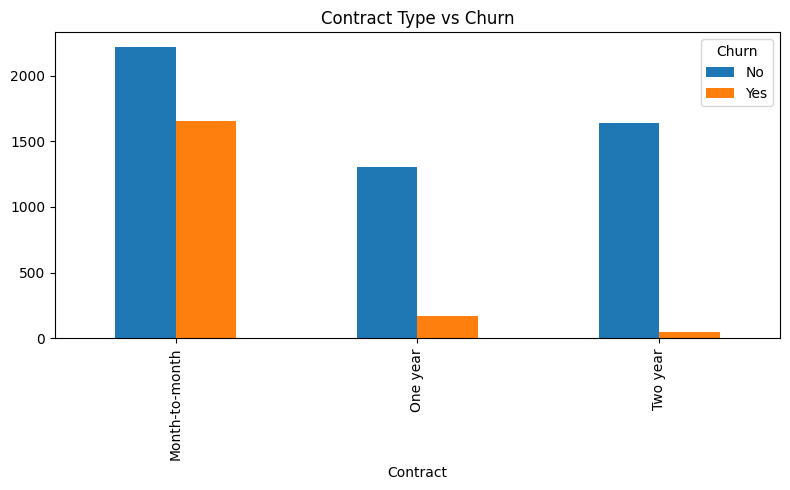

In [30]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn.plot(kind='bar', figsize=(8,5))
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.savefig('images/contract_churn.png')
plt.show()

## Internet Service vs Churn

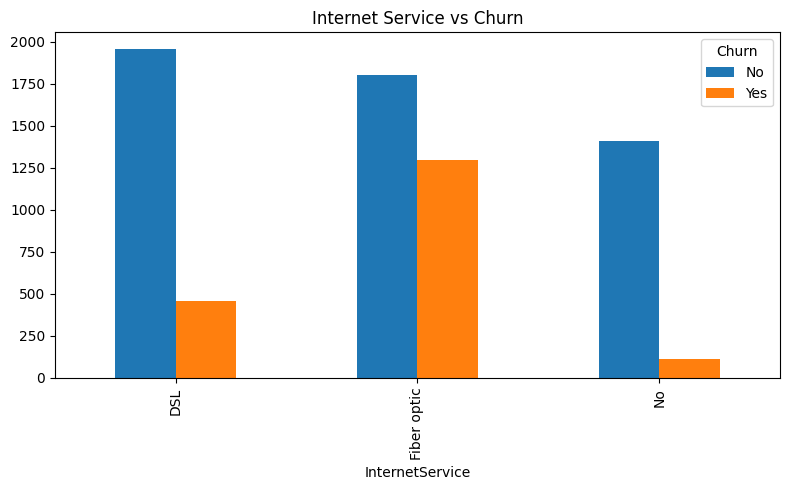

In [31]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'])
internet_churn.plot(kind='bar', figsize=(8,5))
plt.title('Internet Service vs Churn')
plt.tight_layout()
plt.savefig('images/internet_service_churn.png')
plt.show()

## Tenure by Churn

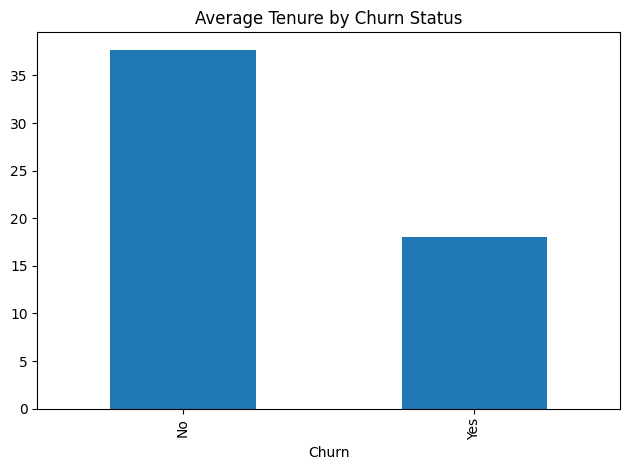

In [32]:
df.groupby('Churn')['tenure'].mean().plot(kind='bar')
plt.title('Average Tenure by Churn Status')
plt.tight_layout()
plt.savefig('images/tenure_churn.png')
plt.show()